In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

file_path = "../data/hotel_bookings.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (119390, 32)
Sütun Adları: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [9]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [10]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [13]:
df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [16]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print((missing / len(df) * 100).round(2))

company     112593
agent        16340
country        488
children         4
dtype: int64
company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64


In [18]:
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df['children'] = df['children'].fillna(0)  
print(df.isna().sum().sum())

0


In [19]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)


month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)
df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


In [20]:
pivot_month_hotel = df.pivot_table(index='arrival_date_month', columns='hotel',
                                     values='is_canceled', aggfunc='count', observed=False)
pivot_month_hotel.columns.name = None
pivot_month_hotel

,City Hotel,Resort Hotel
arrival_date_month,,
January,3736,2193
February,4965,3103
March,6458,3336
April,7480,3609
May,8232,3559
June,7894,3045
July,8088,4573
August,8983,4894
September,7400,3108


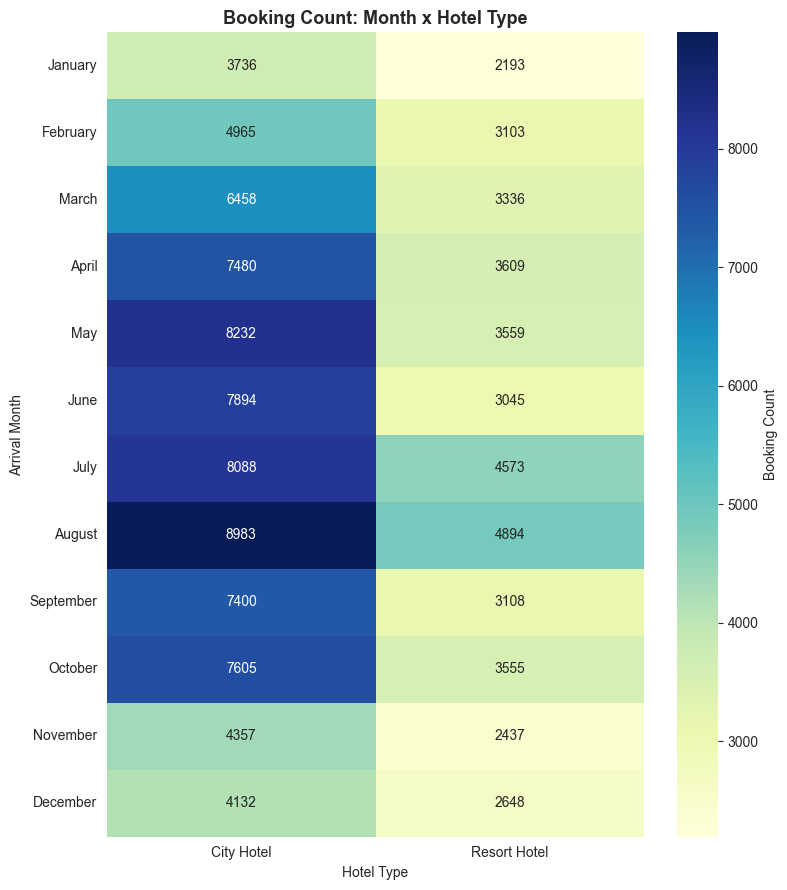

Peak demand month: August (13,877 bookings)
Lowest demand month: January (5,929 bookings)


In [21]:
fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(pivot_month_hotel, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Booking Count'})
ax.set_title('Booking Count: Month x Hotel Type')
ax.set_xlabel('Hotel Type')
ax.set_ylabel('Arrival Month')
plt.tight_layout()
plt.savefig('pivot_month_hotel_heatmap.png', dpi=120)
plt.show()

total_by_month = pivot_month_hotel.sum(axis=1)
print(f"Peak demand month: {total_by_month.idxmax()} ({total_by_month.max():,} bookings)")
print(f"Lowest demand month: {total_by_month.idxmin()} ({total_by_month.min():,} bookings)")

In [22]:
cancel_rate_month_hotel = df.pivot_table(index='arrival_date_month', columns='hotel',
                                          values='is_canceled', aggfunc='mean', observed=False) * 100
cancel_rate_month_hotel.columns.name = None
cancel_rate_month_hotel.round(1)

,City Hotel,Resort Hotel
arrival_date_month,,
January,39.7,14.8
February,38.3,25.6
March,36.9,22.9
April,46.3,29.3
May,44.4,28.8
June,44.7,33.1
July,40.9,31.4
August,40.1,33.4
September,42.0,32.4


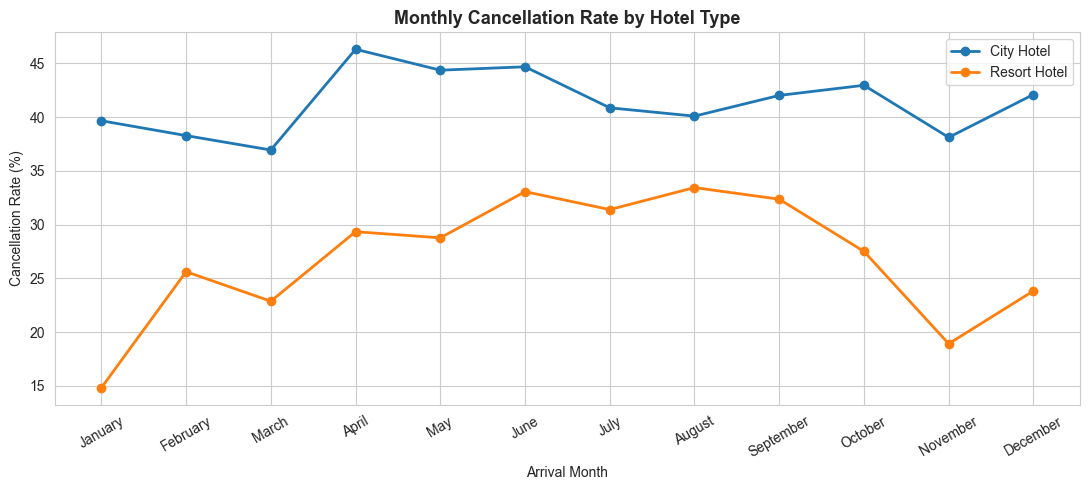

Overall cancellation rate by hotel type:
hotel
City Hotel      41.7
Resort Hotel    27.8
Name: is_canceled, dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
for hotel in cancel_rate_month_hotel.columns:
    ax.plot(cancel_rate_month_hotel.index, cancel_rate_month_hotel[hotel], marker='o', linewidth=2, label=hotel)
ax.set_xlabel('Arrival Month')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Monthly Cancellation Rate by Hotel Type')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('cancellation_rate_by_month.png', dpi=120)
plt.show()
overall_cancel = df.groupby('hotel')['is_canceled'].mean() * 100
print("Overall cancellation rate by hotel type:")
print(overall_cancel.round(1))


In [25]:
lead_time_comparison = df.groupby('is_canceled')['lead_time'].agg(['mean', 'median', 'std'])
lead_time_comparison.index = ['Not Canceled', 'Canceled']
print(lead_time_comparison.round(1))
lead_time_by_hotel = df.groupby(['hotel', 'is_canceled'])['lead_time'].mean().unstack()
lead_time_by_hotel.columns = ['Not Canceled', 'Canceled']
print("\nAverage lead_time by hotel and cancellation status:")
print(lead_time_by_hotel.round(1))

               mean  median    std
Not Canceled   80.0    45.0   91.1
Canceled      144.8   113.0  118.6

Average lead_time by hotel and cancellation status:
              Not Canceled  Canceled
hotel                               
City Hotel            80.7     150.3
Resort Hotel          78.8     128.7


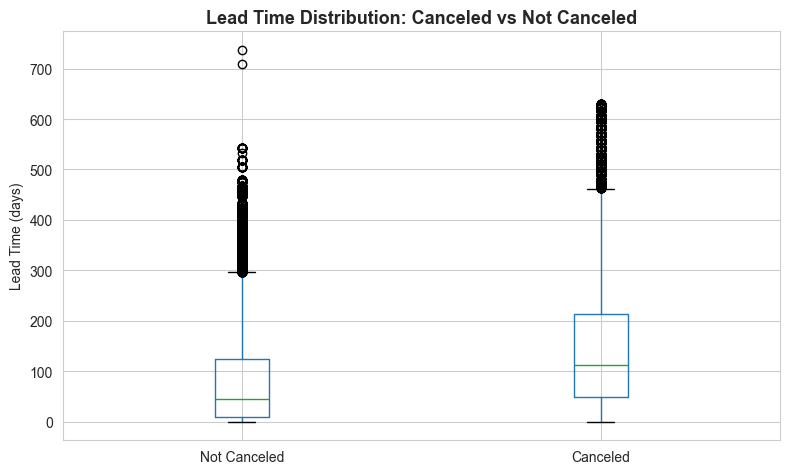

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='lead_time', by='is_canceled', ax=ax)
ax.set_xticklabels(['Not Canceled', 'Canceled'])
ax.set_xlabel('')
ax.set_ylabel('Lead Time (days)')
ax.set_title('Lead Time Distribution: Canceled vs Not Canceled')
plt.suptitle('')
plt.tight_layout()
plt.savefig('lead_time_boxplot.png', dpi=120)
plt.show()

In [27]:
top10_countries = df['country'].value_counts().head(10)

top10_cancel = df[df['country'].isin(top10_countries.index)].groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
)
top10_cancel['cancellation_rate'] = (top10_cancel['cancellation_rate'] * 100).round(1)
top10_cancel = top10_cancel.reindex(top10_countries.index).sort_values('total_bookings', ascending=False)
top10_cancel

,total_bookings,cancellation_rate
country,,
PRT,48590,56.6
GBR,12129,20.2
FRA,10415,18.6
ESP,8568,25.4
DEU,7287,16.7
ITA,3766,35.4
IRL,3375,24.7
BEL,2342,20.2
BRA,2224,37.3


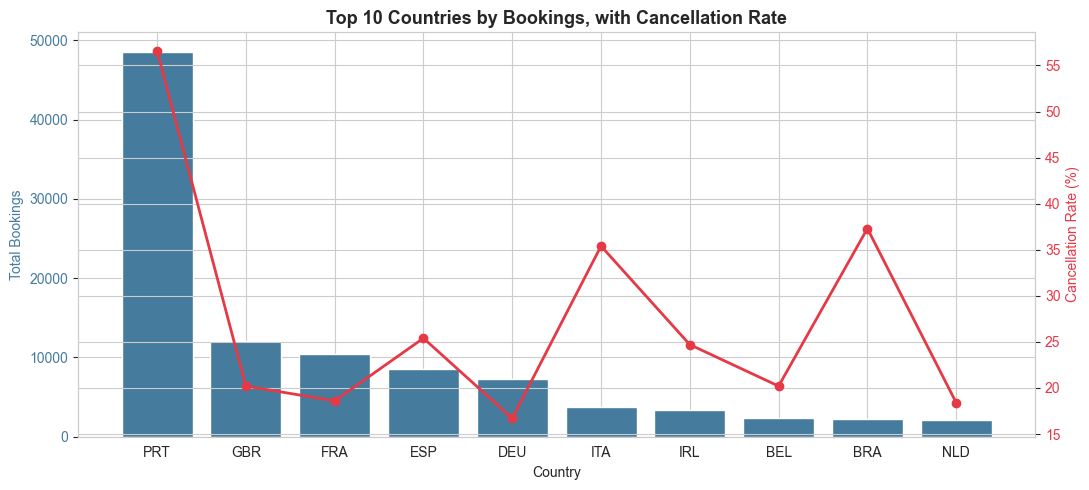

In [28]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(top10_cancel.index, top10_cancel['total_bookings'], color='#457B9D', label='Total Bookings')
ax1.set_xlabel('Country')
ax1.set_ylabel('Total Bookings', color='#457B9D')
ax1.tick_params(axis='y', labelcolor='#457B9D')

ax2 = ax1.twinx()
ax2.plot(top10_cancel.index, top10_cancel['cancellation_rate'], color='#E63946', marker='o', linewidth=2, label='Cancellation Rate')
ax2.set_ylabel('Cancellation Rate (%)', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

ax1.set_title('Top 10 Countries by Bookings, with Cancellation Rate')
plt.tight_layout()
plt.savefig('top10_countries.png', dpi=120)
plt.show()

In [29]:
segment_stats = df.groupby('market_segment').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean'),
    avg_lead_time=('lead_time', 'mean'),
    avg_adr=('adr', 'mean')
).sort_values('total_bookings', ascending=False)
segment_stats['cancellation_rate'] = (segment_stats['cancellation_rate'] * 100).round(1)
segment_stats['share_pct'] = (segment_stats['total_bookings'] / segment_stats['total_bookings'].sum() * 100).round(1)
segment_stats.round(1)

,total_bookings,cancellation_rate,avg_lead_time,avg_adr,share_pct
market_segment,,,,,
Online TA,56477,36.7,83.0,117.2,47.3
Offline TA/TO,24219,34.3,135.0,87.4,20.3
Groups,19811,61.1,187.0,79.5,16.6
Direct,12606,15.3,49.9,115.4,10.6
Corporate,5295,18.7,22.1,69.4,4.4
Complementary,743,13.1,13.3,2.9,0.6
Aviation,237,21.9,4.4,100.1,0.2
Undefined,2,100.0,1.5,15.0,0.0


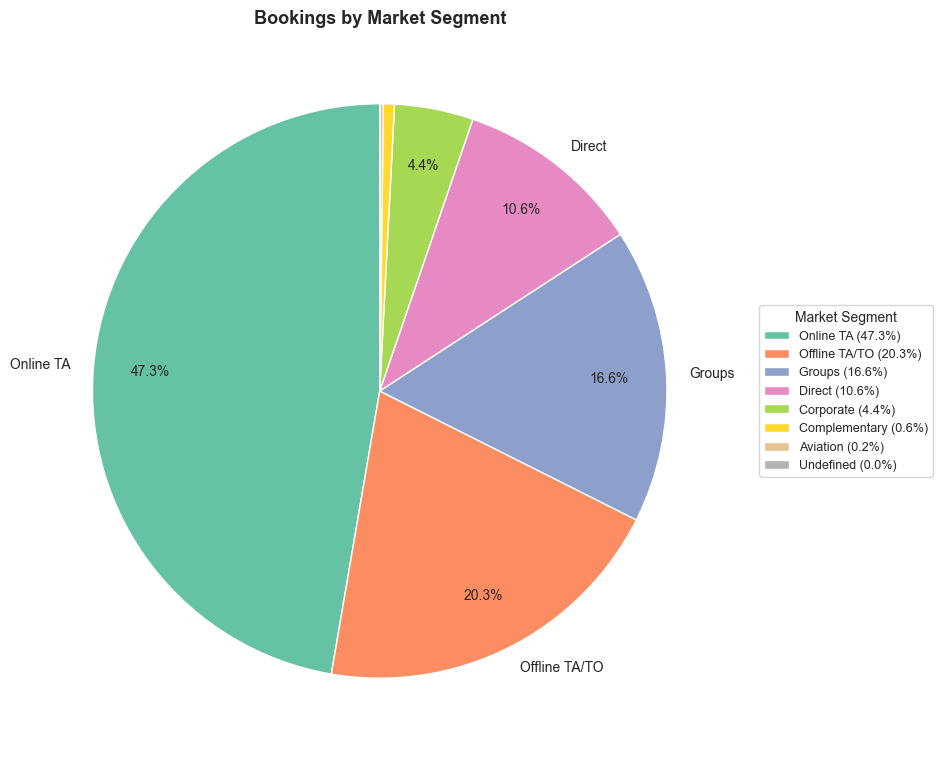

In [33]:
fig, ax = plt.subplots(figsize=(9, 8))
segment_counts = df['market_segment'].value_counts()
colors = sns.color_palette('Set2', len(segment_counts))

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = ax.pie(
    segment_counts.values,
    labels=[name if (v / segment_counts.sum() * 100) >= 5 else '' for name, v in segment_counts.items()],
    autopct=autopct_format,
    colors=colors,
    startangle=90,
    pctdistance=0.8,
    labeldistance=1.08
)

ax.legend(wedges, [f'{name} ({v/segment_counts.sum()*100:.1f}%)' for name, v in segment_counts.items()],
          title='Market Segment', loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

ax.set_title('Bookings by Market Segment')
plt.tight_layout()
plt.savefig('market_segment_pie.png', dpi=120, bbox_inches='tight')
plt.show()

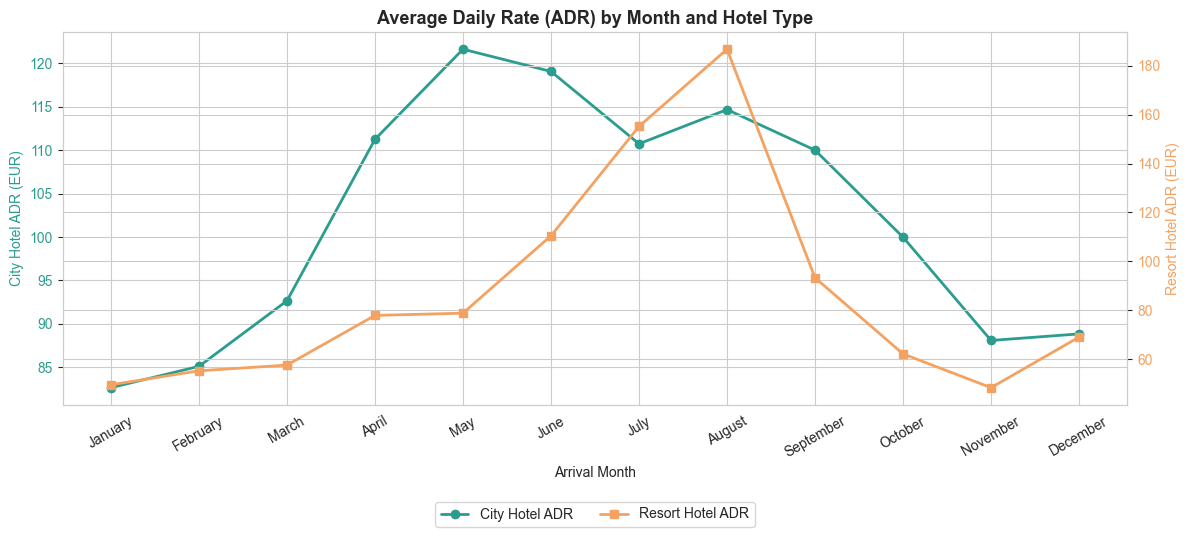

,City Hotel,Resort Hotel
arrival_date_month,,
January,82.6,49.5
February,85.1,55.2
March,92.6,57.5
April,111.3,77.8
May,121.6,78.8
June,119.1,110.4
July,110.7,155.2
August,114.7,186.8
September,110.0,93.3


In [31]:
adr_by_month_hotel = df.pivot_table(index='arrival_date_month', columns='hotel',
                                     values='adr', aggfunc='mean', observed=False)
adr_by_month_hotel.columns.name = None
fig, ax1 = plt.subplots(figsize=(12, 5))
hotel_types = adr_by_month_hotel.columns.tolist()
ax1.plot(adr_by_month_hotel.index, adr_by_month_hotel[hotel_types[0]], color='#2A9D8F', marker='o', linewidth=2, label=f'{hotel_types[0]} ADR')
ax1.set_xlabel('Arrival Month')
ax1.set_ylabel(f'{hotel_types[0]} ADR (EUR)', color='#2A9D8F')
ax1.tick_params(axis='y', labelcolor='#2A9D8F')
plt.setp(ax1.get_xticklabels(), rotation=30)
ax2 = ax1.twinx()
ax2.plot(adr_by_month_hotel.index, adr_by_month_hotel[hotel_types[1]], color='#F4A261', marker='s', linewidth=2, label=f'{hotel_types[1]} ADR')
ax2.set_ylabel(f'{hotel_types[1]} ADR (EUR)', color='#F4A261')
ax2.tick_params(axis='y', labelcolor='#F4A261')
ax1.set_title('Average Daily Rate (ADR) by Month and Hotel Type')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2)
plt.tight_layout()
plt.savefig('adr_by_month_dual_axis.png', dpi=120)
plt.show()
adr_by_month_hotel.round(1)


In [32]:
print(segment_stats[['total_bookings', 'cancellation_rate']].sort_values('cancellation_rate'))
print(f"\nLowest cancellation rate: {segment_stats['cancellation_rate'].idxmin()} at {segment_stats['cancellation_rate'].min()}%")
print(f"Highest cancellation rate: {segment_stats['cancellation_rate'].idxmax()} at {segment_stats['cancellation_rate'].max()}%")


                total_bookings  cancellation_rate
market_segment                                   
Complementary              743               13.1
Direct                   12606               15.3
Corporate                 5295               18.7
Aviation                   237               21.9
Offline TA/TO            24219               34.3
Online TA                56477               36.7
Groups                   19811               61.1
Undefined                    2              100.0

Lowest cancellation rate: Complementary at 13.1%
Highest cancellation rate: Undefined at 100.0%
